# Bivariate Exploratory Data Analysis

In this notebook I will perform bivariate analysis to understand the relationship between features and the target variable (`is_cancelled`).

## Objectives
1. Analyze each feature's relationship with cancellation
2. Identify the strongest predictors
3. Discover patterns that can inform feature engineering
4. Validate hypotheses from univariate analysis

## Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
data = pd.read_parquet("../data/bronze/clean_dataset.parquet", engine='pyarrow')
data = data.sort_values(["date", "time"]).reset_index(drop=True)

print(f"Dataset shape: {data.shape}")
print(f"Cancellation rate: {data['is_cancelled'].mean():.2%}")
data.head()

Dataset shape: (150000, 13)
Cancellation rate: 32.00%


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [4]:
# Prepare data - remove leaking columns and create temporal features
df = data.copy()

# Create datetime and temporal features
df['datetime'] = pd.to_datetime(df['date'] + " " + df['time'], format="%Y-%m-%d %H:%M:%S")
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Remove features that leak information (only available after booking outcome)
# These have NaN only for cancelled bookings
leaking_cols = ["avg_ctat", "booking_value", "ride_distance", "payment_method"]
df.drop(columns=leaking_cols, inplace=True)

# Create VTAT bins
bins = [0, 5, 10, 15, 20]
labels = ["0-5", "5-10", "10-15", "15-20"]
df["vtat_bucket"] = pd.cut(df["avg_vtat"], bins=bins, labels=labels).astype("category")

print(f"Columns available for analysis: {df.columns.tolist()}")
df.head()

Columns available for analysis: ['date', 'time', 'booking_id', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat', 'is_cancelled', 'datetime', 'hour', 'dayofweek', 'month', 'is_weekend', 'vtat_bucket']


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,dayofweek,month,is_weekend,vtat_bucket
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,0.0,2024-01-01 00:19:34,0,0,1,0,10-15
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,0.0,2024-01-01 01:35:18,1,0,1,0,5-10
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,1.0,2024-01-01 01:37:50,1,0,1,0,5-10
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,1.0,2024-01-01 01:48:03,1,0,1,0,5-10
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,1.0,2024-01-01 01:49:56,1,0,1,0,5-10



## 1. VTAT (Wait Time) vs Target

Higher wait times lead to more cancellations??

In [ ]:
# Statistical test: Point-biserial correlation
vtat_clean = df.dropna(subset=['avg_vtat'])
corr, p_value = stats.pointbiserialr(vtat_clean['is_cancelled'], vtat_clean['avg_vtat'])

print("VTAT vs CANCELLATION - STATISTICAL TEST")
print("-" * 60)
print(f"\nPoint-biserial correlation: {corr:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"\nInterpretation: {'Significant' if p_value < 0.05 else 'Not significant'} correlation")

VTAT vs CANCELLATION - STATISTICAL TEST

Point-biserial correlation: 0.0721
P-value: 5.36e-160

Interpretation: Significant correlation


In [6]:
# Compare VTAT distributions
vtat_completed = df[df['is_cancelled'] == 0]['avg_vtat'].dropna()
vtat_cancelled = df[df['is_cancelled'] == 1]['avg_vtat'].dropna()

print("\nVTAT Statistics by Outcome:")
print("-" * 40)
print(f"Completed rides: Mean = {vtat_completed.mean():.2f} min, Median = {vtat_completed.median():.2f} min")
print(f"Cancelled rides: Mean = {vtat_cancelled.mean():.2f} min, Median = {vtat_cancelled.median():.2f} min")
print(f"Difference in means: {vtat_cancelled.mean() - vtat_completed.mean():.2f} min")

# T-test
t_stat, t_pvalue = stats.ttest_ind(vtat_completed, vtat_cancelled)
print(f"\nT-test: t = {t_stat:.2f}, p = {t_pvalue:.2e}")


VTAT Statistics by Outcome:
----------------------------------------
Completed rides: Mean = 8.29 min, Median = 8.20 min
Cancelled rides: Mean = 8.90 min, Median = 8.40 min
Difference in means: 0.61 min

T-test: t = -26.99, p = 5.35e-160


In [7]:
# Cancellation rate by VTAT bucket
vtat_analysis = df.groupby('vtat_bucket', observed=True).agg({
    'is_cancelled': ['mean', 'count', 'sum']
}).round(4)
vtat_analysis.columns = ['Cancellation Rate', 'Total Bookings', 'Cancellations']

print("\nCancellation Rate by VTAT Bucket:")
print(vtat_analysis)


Cancellation Rate by VTAT Bucket:
             Cancellation Rate  Total Bookings  Cancellations
vtat_bucket                                                  
0-5                     0.1987           31311         6221.0
5-10                    0.3083           59896        18467.0
10-15                   0.2075           44772         9291.0
15-20                   1.0000            3521         3521.0


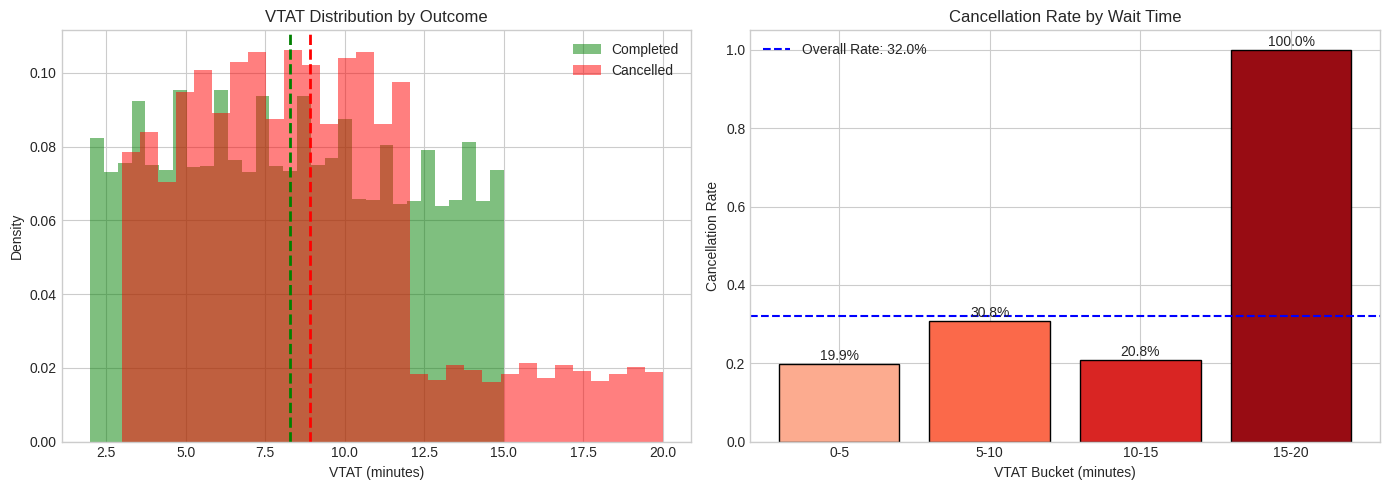

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison of distributions
ax1 = axes[0]
ax1.hist(vtat_completed, bins=30, alpha=0.5, label='Completed', color='green', density=True)
ax1.hist(vtat_cancelled, bins=30, alpha=0.5, label='Cancelled', color='red', density=True)
ax1.axvline(vtat_completed.mean(), color='green', linestyle='--', linewidth=2)
ax1.axvline(vtat_cancelled.mean(), color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('VTAT (minutes)')
ax1.set_ylabel('Density')
ax1.set_title('VTAT Distribution by Outcome')
ax1.legend()

# Cancellation rate by waiting time bucket
ax2 = axes[1]
vtat_rates = df.groupby('vtat_bucket', observed=True)['is_cancelled'].mean()
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(vtat_rates)))
bars = ax2.bar(vtat_rates.index.astype(str), vtat_rates.values, color=colors, edgecolor='black')
ax2.axhline(y=df['is_cancelled'].mean(), color='blue', linestyle='--', 
            label=f'Overall Rate: {df["is_cancelled"].mean():.1%}')
ax2.set_xlabel('VTAT Bucket (minutes)')
ax2.set_ylabel('Cancellation Rate')
ax2.set_title('Cancellation Rate by Wait Time')
ax2.legend()

for bar, rate in zip(bars, vtat_rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{rate:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

VTAT > 15 minutes shows 100% cancellation rate. This is a critical threshold for intervention.

## 2. Vehicle Type vs Target

In [ ]:
# Cancellation rate by vehicle type
vehicle_analysis = df.groupby('vehicle_type', observed=True).agg({
    'is_cancelled': ['mean', 'count', 'sum']
}).round(4)
vehicle_analysis.columns = ['Cancellation Rate', 'Total Bookings', 'Cancellations']
vehicle_analysis = vehicle_analysis.sort_values('Cancellation Rate', ascending=False)

print("CANCELLATION RATE BY VEHICLE TYPE")
print("-" * 60)
print(vehicle_analysis)

CANCELLATION RATE BY VEHICLE TYPE
               Cancellation Rate  Total Bookings  Cancellations
vehicle_type                                                   
Go Sedan                  0.3251           27141         8823.0
Auto                      0.3208           37419        12004.0
Premier Sedan             0.3200           18111         5796.0
eBike                     0.3198           10557         3376.0
Bike                      0.3178           22517         7155.0
Go Mini                   0.3168           29806         9442.0
Uber XL                   0.3156            4449         1404.0


In [10]:
# Chi-square test for independence
contingency = pd.crosstab(df['vehicle_type'], df['is_cancelled'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square test:")
print(f"  Chi2 = {chi2:.2f}")
print(f"  P-value = {p_value:.2e}")
print(f"  Degrees of freedom = {dof}")
print(f"\nInterpretation: {'Significant' if p_value < 0.05 else 'Not significant'} association")


Chi-square test:
  Chi2 = 5.67
  P-value = 4.61e-01
  Degrees of freedom = 6

Interpretation: Not significant association


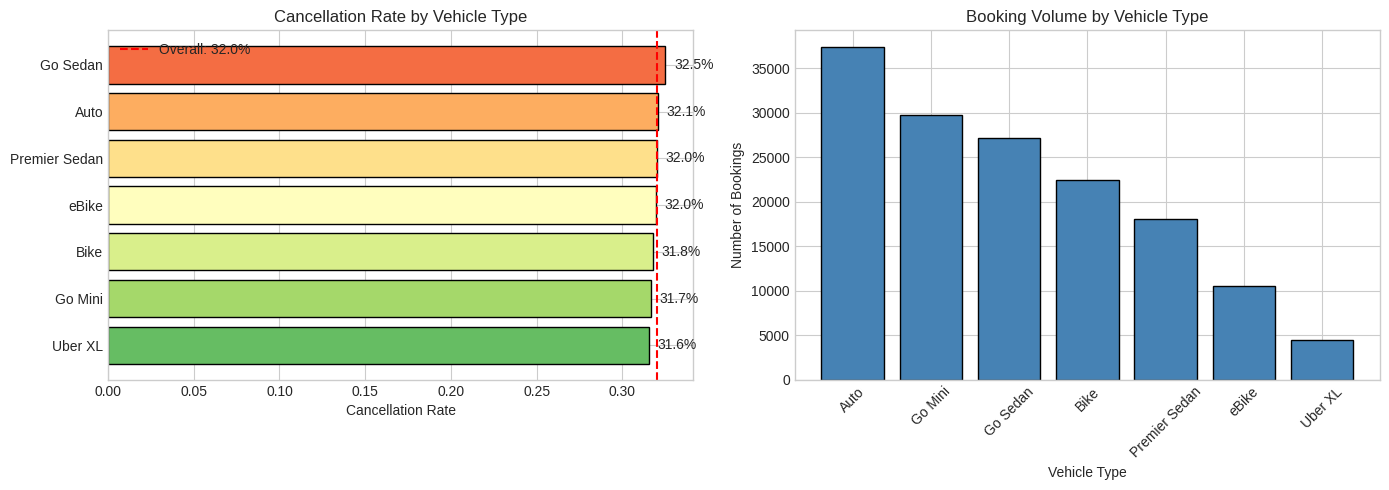

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
vehicle_rates = df.groupby('vehicle_type', observed=True)['is_cancelled'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(vehicle_rates)))
bars = ax1.barh(vehicle_rates.index.astype(str), vehicle_rates.values, color=colors, edgecolor='black')
ax1.axvline(x=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax1.set_xlabel('Cancellation Rate')
ax1.set_title('Cancellation Rate by Vehicle Type')
ax1.legend()

for bar, rate in zip(bars, vehicle_rates.values):
    ax1.text(rate + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{rate:.1%}', va='center', fontsize=10)

ax2 = axes[1]
vehicle_counts = df['vehicle_type'].value_counts()
ax2.bar(vehicle_counts.index.astype(str), vehicle_counts.values, color='steelblue', edgecolor='black')
ax2.set_xlabel('Vehicle Type')
ax2.set_ylabel('Number of Bookings')
ax2.set_title('Booking Volume by Vehicle Type')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

All vehicle types have similar cancellation rates (~32%). Vehicle type alone is NOT a strong predictor.


## 3. Temporal Features vs Target

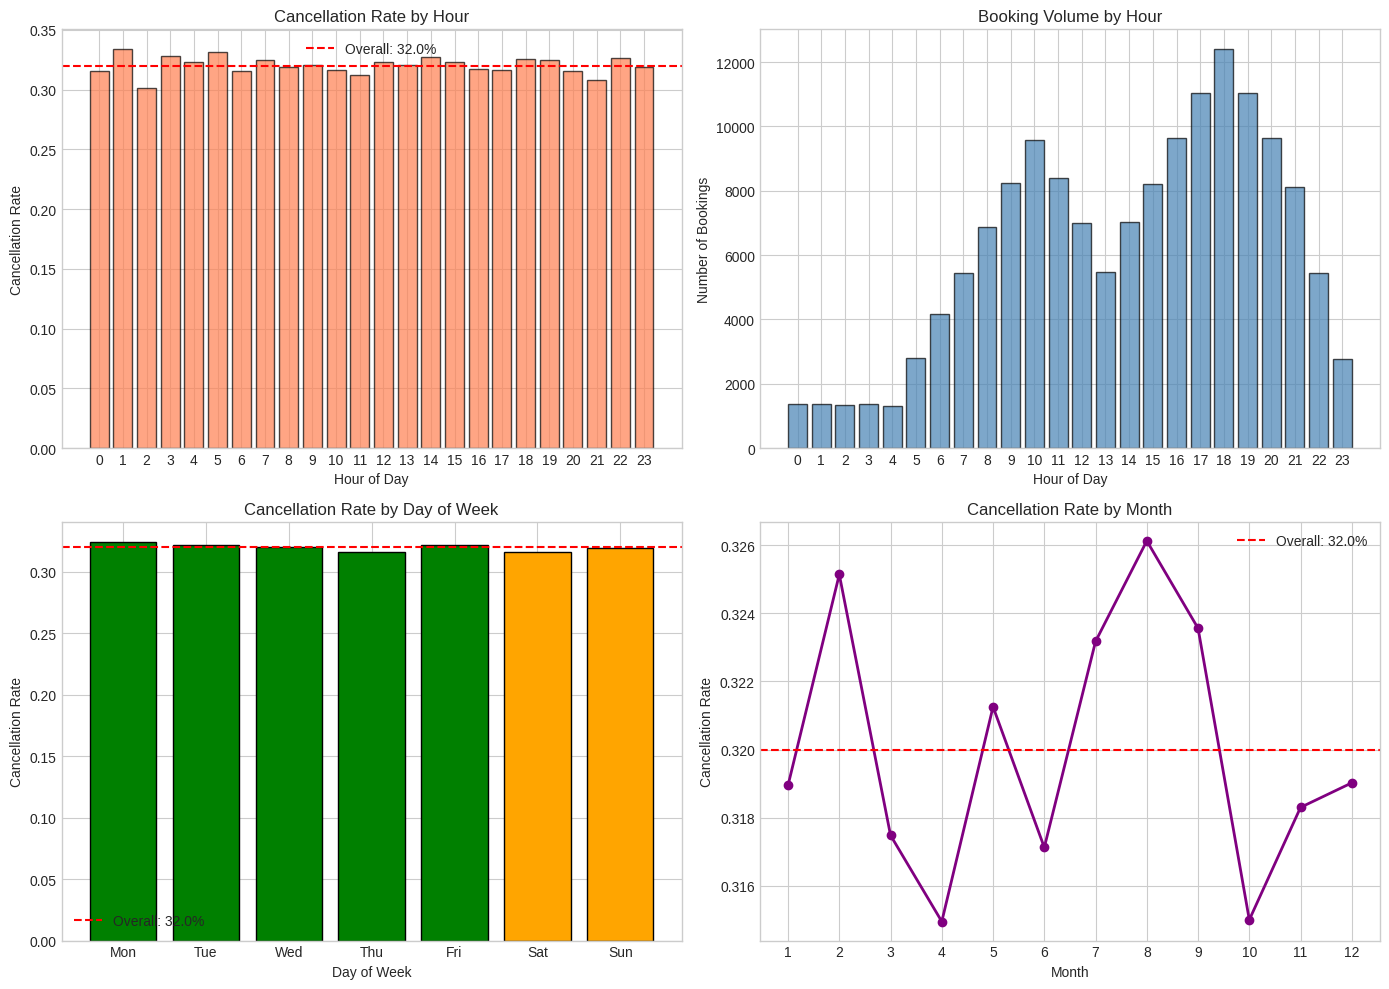

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly cancellation rate
ax1 = axes[0, 0]
hourly_rate = df.groupby('hour')['is_cancelled'].mean()
ax1.bar(hourly_rate.index, hourly_rate.values, color='coral', edgecolor='black', alpha=0.7)
ax1.axhline(y=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Cancellation Rate')
ax1.set_title('Cancellation Rate by Hour')
ax1.legend()
ax1.set_xticks(range(0, 24))

# Hourly volume
ax2 = axes[0, 1]
hourly_count = df.groupby('hour')['is_cancelled'].count()
ax2.bar(hourly_count.index, hourly_count.values, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Bookings')
ax2.set_title('Booking Volume by Hour')
ax2.set_xticks(range(0, 24))

# Day of week
ax3 = axes[1, 0]
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_rate = df.groupby('dayofweek')['is_cancelled'].mean()
colors = ['green' if i < 5 else 'orange' for i in range(7)]
ax3.bar(dow_names, dow_rate.values, color=colors, edgecolor='black')
ax3.axhline(y=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Cancellation Rate')
ax3.set_title('Cancellation Rate by Day of Week')
ax3.legend()

# Monthly trend
ax4 = axes[1, 1]
monthly_rate = df.groupby('month')['is_cancelled'].mean()
ax4.plot(monthly_rate.index, monthly_rate.values, marker='o', linewidth=2, color='purple')
ax4.axhline(y=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax4.set_xlabel('Month')
ax4.set_ylabel('Cancellation Rate')
ax4.set_title('Cancellation Rate by Month')
ax4.set_xticks(range(1, 13))
ax4.legend()

plt.tight_layout()
plt.show()

In [13]:
# Weekend vs Weekday
weekend_analysis = df.groupby('is_weekend').agg({
    'is_cancelled': ['mean', 'count']
}).round(4)
weekend_analysis.columns = ['Cancellation Rate', 'Total Bookings']
weekend_analysis.index = ['Weekday', 'Weekend']

print("\nWeekend vs Weekday:")
print(weekend_analysis)


Weekend vs Weekday:
         Cancellation Rate  Total Bookings
Weekday             0.3209          107060
Weekend             0.3177           42940


Cancellation rate is remarkably flat across hours, days, and months. Temporal features alone are weak predictors.


## 4. Location Analysis

In [24]:
# Top pickup locations by cancellation rate
pickup_analysis = df.groupby('pickup_location', observed=True).agg({
    'is_cancelled': ['mean', 'count']
}).round(4)
pickup_analysis.columns = ['Cancellation Rate', 'Total Bookings']

# Filter locations with at least 100 bookings for reliability
pickup_reliable = pickup_analysis[pickup_analysis['Total Bookings'] >= 100]

print("TOP 10 PICKUP LOCATIONS BY CANCELLATION RATE")
print("-" * 60)
print(pickup_reliable.sort_values('Cancellation Rate', ascending=False).head(10))


print("\nBOTTOM 10 PICKUP LOCATIONS BY CANCELLATION RATE")
print("-" * 60)
print(pickup_reliable.sort_values('Cancellation Rate', ascending=True).head(10))

TOP 10 PICKUP LOCATIONS BY CANCELLATION RATE
------------------------------------------------------------
                      Cancellation Rate  Total Bookings
pickup_location                                        
Vinobapuri                       0.3888             823
Akshardham                       0.3659             839
Faridabad Sector 15              0.3598             831
Netaji Subhash Place             0.3566             830
Qutub Minar                      0.3524             823
Vatika Chowk                     0.3517             833
Badshahpur                       0.3514             868
Chhatarpur                       0.3510             829
Karkarduma                       0.3493             836
Shahdara                         0.3488             820

BOTTOM 10 PICKUP LOCATIONS BY CANCELLATION RATE
------------------------------------------------------------
                 Cancellation Rate  Total Bookings
pickup_location                                   
Kanhaiya N

In [19]:
print(f"\nUnique pickup locations: {df['pickup_location'].nunique()}")
print(f"Unique drop locations: {df['drop_location'].nunique()}\n")
print("---"*40)
location_rates = pickup_reliable['Cancellation Rate']
print(f"\nCancellation rate distribution across locations:")
print(f"  Min: {location_rates.min():.2%}")
print(f"  Max: {location_rates.max():.2%}")
print(f"  Mean: {location_rates.mean():.2%}")
print(f"  Std: {location_rates.std():.2%}")


Unique pickup locations: 176
Unique drop locations: 176

------------------------------------------------------------------------------------------------------------------------

Cancellation rate distribution across locations:
  Min: 28.04%
  Max: 38.88%
  Mean: 32.01%
  Std: 1.73%


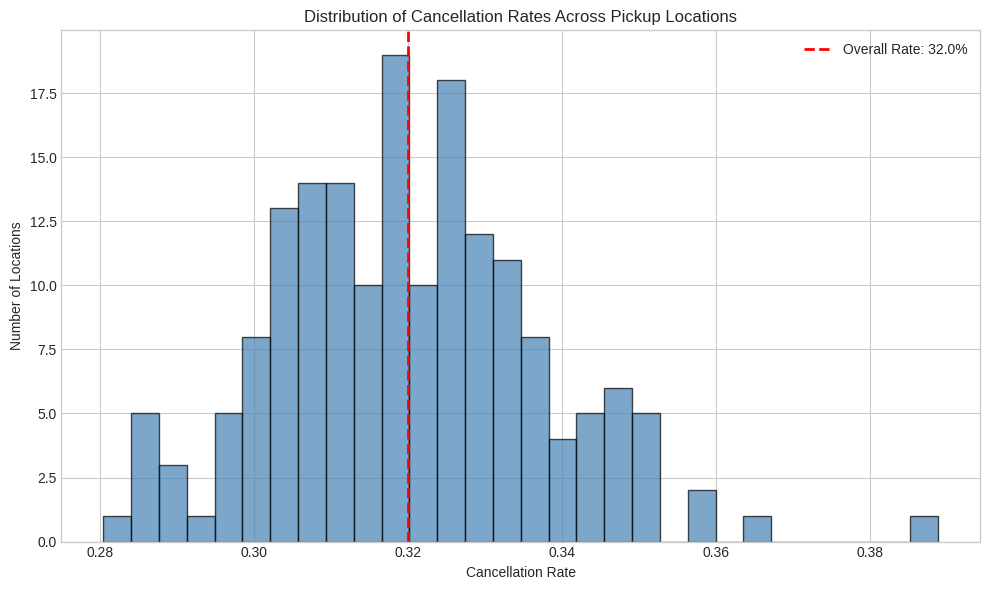

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(location_rates, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=df['is_cancelled'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Overall Rate: {df["is_cancelled"].mean():.1%}')
ax.set_xlabel('Cancellation Rate')
ax.set_ylabel('Number of Locations')
ax.set_title('Distribution of Cancellation Rates Across Pickup Locations')
ax.legend()
plt.tight_layout()
plt.show()

There is variation in cancellation rates across locations, but with 176 unique locations, we need target encoding rather than one-hot encoding for modeling.